# 2 多层感知机

## 2.1 理论计算题

**1. 非线性激活函数的重要性：**
已知隐藏层无激活函数（即线性激活）：$\mathbf{h} = \mathbf{W}_1\mathbf{x} + \mathbf{b}_1$，输出层为 $\mathbf{o} = \mathbf{W}_2\mathbf{h} + \mathbf{b}_2$。
将隐藏层代入输出层中：
$$ \mathbf{o} = \mathbf{W}_2(\mathbf{W}_1\mathbf{x} + \mathbf{b}_1) + \mathbf{b}_2 = (\mathbf{W}_2\mathbf{W}_1)\mathbf{x} + (\mathbf{W}_2\mathbf{b}_1 + \mathbf{b}_2) $$
这等价于一个没有任何隐藏层的单层神经网络 $\mathbf{o} = \mathbf{W}'\mathbf{x} + \mathbf{b}'$，其中等价的权重矩阵和偏置向量为：
$$ \mathbf{W}' = \mathbf{W}_2\mathbf{W}_1, \quad \mathbf{b}' = \mathbf{W}_2\mathbf{b}_1 + \mathbf{b}_2 $$
**结论：** 如果不使用非线性激活函数，无论堆叠多少层隐藏层，多层感知机都会退化为简单的单层线性网络，无法学习复杂的非线性映射。

**2. 激活函数性质分析：**

**Sigmoid(x) 函数及导数：**
$$ \text{Sigmoid}(x) = \sigma(x) = \frac{1}{1 + e^{-x}} $$
求导：
$$ \sigma'(x) = \frac{0 - 1 \cdot (-e^{-x})}{(1 + e^{-x})^2} = \frac{e^{-x}}{(1 + e^{-x})^2} = \frac{1}{1 + e^{-x}} \cdot \frac{e^{-x}}{1 + e^{-x}} = \sigma(x)(1 - \sigma(x)) $$

**$\tanh(x)$ 函数及导数：**
$$ \tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}} $$
求导：
$$ \tanh'(x) = \frac{(e^x + e^{-x})(e^x + e^{-x}) - (e^x - e^{-x})(e^x - e^{-x})}{(e^x + e^{-x})^2} = \frac{(e^x + e^{-x})^2 - (e^x - e^{-x})^2}{(e^x + e^{-x})^2} = 1 - \tanh^2(x) $$

## 2.2 编程题
不使用深度学习框架的高级 API，从零实现单隐藏层 MLP 进行分类（Fashion-MNIST 数据集）。

当前训练终端设备: cuda
Epoch 01 | 损失: 1.0426 | 训练集准确率: 0.6370 | 测试集准确率: 0.7563
Epoch 05 | 损失: 0.4514 | 训练集准确率: 0.8419 | 测试集准确率: 0.8345
Epoch 10 | 损失: 0.3827 | 训练集准确率: 0.8646 | 测试集准确率: 0.8522
Epoch 15 | 损失: 0.3443 | 训练集准确率: 0.8779 | 测试集准确率: 0.8603
Epoch 20 | 损失: 0.3196 | 训练集准确率: 0.8851 | 测试集准确率: 0.8701
Epoch 25 | 损失: 0.3025 | 训练集准确率: 0.8909 | 测试集准确率: 0.8746
Epoch 30 | 损失: 0.2844 | 训练集准确率: 0.8976 | 测试集准确率: 0.8759


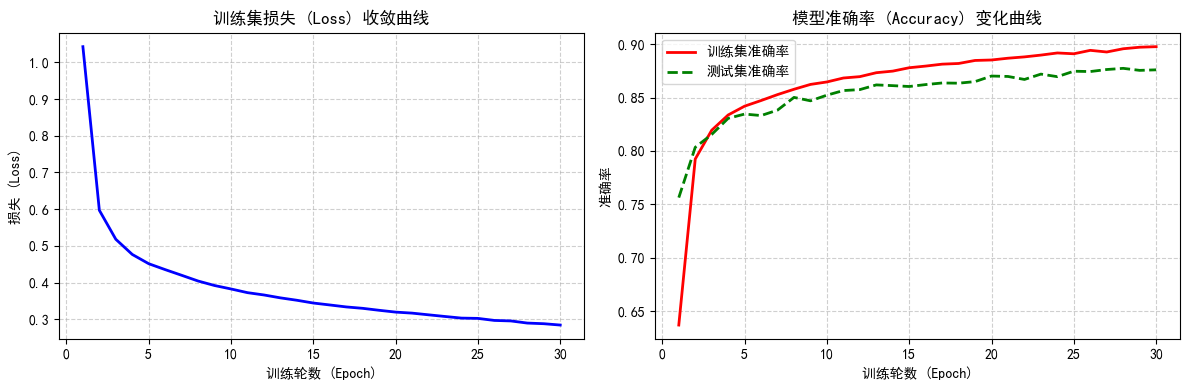

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# ==================== 配置可视化中文字体 ====================
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# ==================== 数据准备 ====================
# 获取设备 (使用 cuda 时速度会大幅度提升)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"当前训练终端设备: {device}")

batch_size = 256
transform = transforms.ToTensor()
# 将数据集下载路径修改为当前目录下的 HW02 文件夹
train_dataset = torchvision.datasets.FashionMNIST(root='./HW02/data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.FashionMNIST(root='./HW02/data', train=False, transform=transform, download=True)

train_iter = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_iter = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# ==================== 1. 参数初始化 ====================
num_inputs, num_outputs, num_hiddens = 784, 10, 256

# 【修正崩溃危险】使用 torch.normal 直接安全创建叶子张量(Leaf Tensor)，避免复合操作丢失梯度关联或引发内存泄漏
W1 = torch.normal(0, 0.01, size=(num_inputs, num_hiddens), device=device, requires_grad=True)
b1 = torch.zeros(num_hiddens, device=device, requires_grad=True)
W2 = torch.normal(0, 0.01, size=(num_hiddens, num_outputs), device=device, requires_grad=True)
b2 = torch.zeros(num_outputs, device=device, requires_grad=True)

params = [W1, b1, W2, b2]

# ==================== 2. ReLU 和模型前向 ====================
def relu(X):
    # 使用纯 Tensor 操作实现 max(0, x)，确保不崩溃且符合要求
    return torch.maximum(X, torch.zeros_like(X))

def net(X):
    X = X.reshape((-1, num_inputs)) # 展平
    H = relu(X @ W1 + b1)
    return H @ W2 + b2

# ==================== 3. 交叉熵损失 ====================
def cross_entropy(y_hat, y):
    # 结合 softmax 和交叉熵以保证数值稳定性
    exp_y_hat = torch.exp(y_hat - torch.max(y_hat, dim=1, keepdim=True).values)
    softmax_y_hat = exp_y_hat / torch.sum(exp_y_hat, dim=1, keepdim=True)
    # 【修复崩溃点】使用同 device 的 torch.arange 替换原来 Python原生的 range() 避免引发跨设备段错误
    # 同时在 log 中增加 1e-8 防止 log(0) 出现数值无穷大导致底层崩溃
    indices = torch.arange(len(y_hat), device=y_hat.device)
    return -torch.log(softmax_y_hat[indices, y] + 1e-8)

# ==================== 4. 训练循环 (SGD) 和 可视化 ====================
def sgd(params, lr, batch_size):
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

def evaluate_accuracy(net, data_iter):
    acc_sum, n = 0.0, 0
    with torch.no_grad():
        for X, y in data_iter:
            X, y = X.to(device), y.to(device) # 测试数据移动到设备上
            acc_sum += (net(X).argmax(dim=1) == y).float().sum().item()
            n += y.shape[0]
    return acc_sum / n

def train_mlp():
    lr = 0.1
    num_epochs = 30
    
    # 记录数据用于画图
    train_losses, train_accs, test_accs = [], [], []
    
    for epoch in range(num_epochs):
        train_l_sum, train_acc_sum, n = 0.0, 0.0, 0
        for X, y in train_iter:
            X, y = X.to(device), y.to(device) # 数据移动到计算设备 (GPU或CPU)
            y_hat = net(X)
            l = cross_entropy(y_hat, y).sum()
            
            l.backward() # 反向传播求梯度
            sgd(params, lr, batch_size) # SGD 更新
            
            train_l_sum += l.item()
            train_acc_sum += (y_hat.argmax(dim=1) == y).float().sum().item()
            n += y.shape[0]
            
        test_acc = evaluate_accuracy(net, test_iter)
        
        train_losses.append(train_l_sum / n)
        train_accs.append(train_acc_sum / n)
        test_accs.append(test_acc)
        
        # 减少打印频率，只打印关键轮次
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:02d} | 损失: {train_l_sum/n:.4f} | 训练集准确率: {train_acc_sum/n:.4f} | 测试集准确率: {test_acc:.4f}")
    
    # 训练完毕后，绘制变化曲线
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(range(1, num_epochs + 1), train_losses, 'b-', linewidth=2)
    plt.title('训练集损失 (Loss) 收敛曲线')
    plt.xlabel('训练轮数 (Epoch)')
    plt.ylabel('损失 (Loss)')
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.subplot(1, 2, 2)
    plt.plot(range(1, num_epochs + 1), train_accs, 'r-', linewidth=2, label='训练集准确率')
    plt.plot(range(1, num_epochs + 1), test_accs, 'g--', linewidth=2, label='测试集准确率')
    plt.title('模型准确率 (Accuracy) 变化曲线')
    plt.xlabel('训练轮数 (Epoch)')
    plt.ylabel('准确率')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()
    
    return net

model = train_mlp()

# 3 模型选择，权重衰减和丢弃法

## 3.1 理论计算题

**1. 过拟合与欠拟合：**
* **区别：** 训练误差是模型在训练数据集上的表现误差；泛化误差是模型在新数据（或测试集）上的预期误差。
* **模型状态：** 当训练误差极低而泛化误差很高时，模型处于**过拟合 (Overfitting)**状态。这意味着模型“死记硬背”了训练集中的噪音或特有特征。
* **缓解方法：** 控制模型复杂度。可以通过：减少参数数量（减少层数、单元数）、引入正则化（如 $L_2, L_1$ 正则化，即权重衰减）、使用 Dropout（丢弃法）、提早停止 (Early Stopping) 或增加数据量。

**2. K折交叉验证实施步骤：**
1. 将原始训练数据集随机划分为 $K$ 个大小相似互不重叠的子集（Fold）。
2. 在接下来的 $K$ 次迭代中，每次选择其中 1 个子集作为验证集，剩下的 $K-1$ 个子集合并作为训练集。
3. 在这 $K-1$ 个子集上训练模型，并在那被选出的 1 个验证集上计算误差及指标。
4. 重复上述步骤 $K$ 次，每个子集都会且仅会被作为一次验证集。
5. 将 $K$ 次验证得到的结果取平均，用来评估模型的泛化性能并选择超参数。

## 3.2 编程题
实现带有 $L_2$ 正则化和 Dropout 的 MLP，并进行实验对比。

正在训练 1)基准模型...
[无正则化] Epoch 10/30 | 训练 Loss: 1.4548 | 验证 Loss: 1.4193
[无正则化] Epoch 20/30 | 训练 Loss: 0.9503 | 验证 Loss: 0.9890
[无正则化] Epoch 30/30 | 训练 Loss: 0.8152 | 验证 Loss: 0.8685

正在训练 2)带权重衰减(L2)模型...
[权重衰减(L2)] Epoch 10/30 | 训练 Loss: 1.4964 | 验证 Loss: 1.4553
[权重衰减(L2)] Epoch 20/30 | 训练 Loss: 0.9603 | 验证 Loss: 0.9823
[权重衰减(L2)] Epoch 30/30 | 训练 Loss: 0.7824 | 验证 Loss: 0.8413

正在训练 3)带Dropout模型...
[Dropout] Epoch 10/30 | 训练 Loss: 1.5097 | 验证 Loss: 1.4425
[Dropout] Epoch 20/30 | 训练 Loss: 1.0403 | 验证 Loss: 1.0082
[Dropout] Epoch 30/30 | 训练 Loss: 0.8617 | 验证 Loss: 0.8576


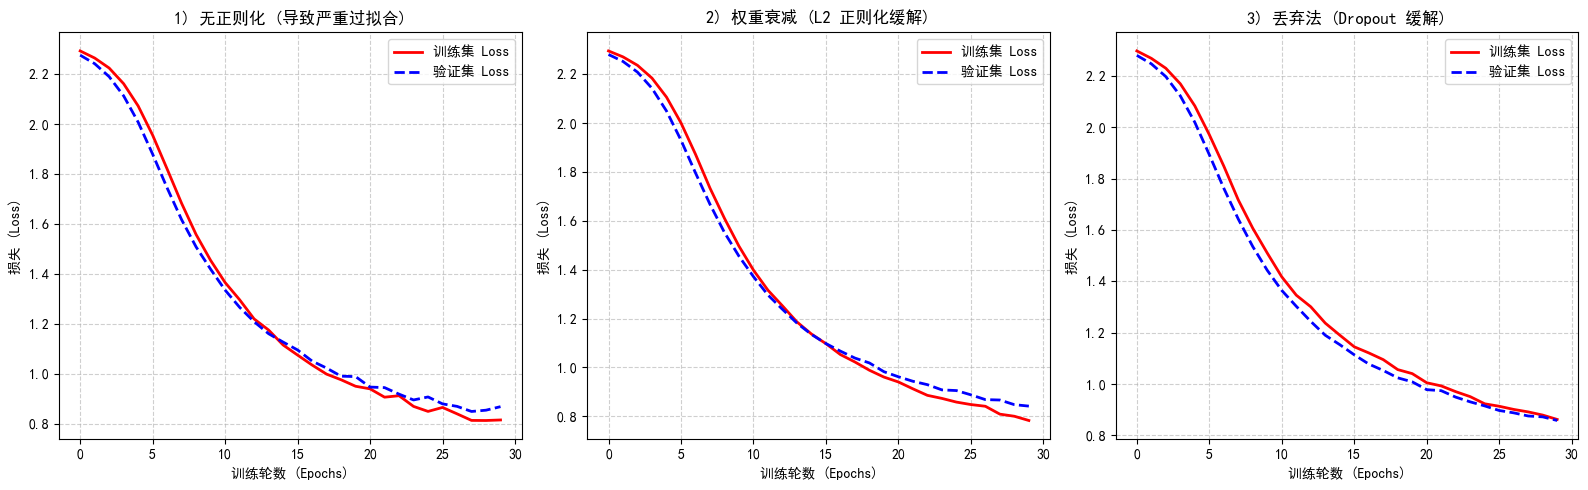

In [2]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# ==================== 1. 自定义带有权重衰减的 SGD ====================
def sgd_weight_decay(params, lr, batch_size, weight_decay):
    with torch.no_grad():
        for param in params:
            # 权重衰减 (L2 正则化在梯度更新时的等价形式): w = w * (1 - lr * weight_decay) - lr * grad
            param.copy_(param * (1 - lr * weight_decay))
            param -= lr * param.grad / batch_size
            param.grad.zero_()

# ==================== 2. Dropout 从零实现 ====================
def dropout_layer(X, dropout):
    assert 0 <= dropout <= 1
    # 如果丢弃率是 1，所有元素都被丢弃
    if dropout == 1:
        return torch.zeros_like(X)
    # 如果丢弃率是 0，原样返回
    if dropout == 0:
        return X
    # 生成随机掩码 mask, 指定与X相同的device
    mask = (torch.rand(X.shape, device=X.device) > dropout).float()
    # 丢弃并进行缩放
    return mask * X / (1.0 - dropout)

# ==================== 3. 包含 Dropout 的网络前向传播 ====================
def net_with_dropout(X, W1, b1, W2, b2, drop_prob, is_training=True):
    X = X.reshape((-1, num_inputs)) # 展平
    H1 = relu(X @ W1 + b1)
    if is_training:
        H1 = dropout_layer(H1, drop_prob)
    return H1 @ W2 + b2

# ==================== 4. 对比实验 ====================
# 【重要修正】按作业要求，通过构造一个只有 1000 个样本的极少样本子集来轻易诱发严重的过拟合现象
small_train_dataset = torch.utils.data.Subset(train_dataset, range(1000))
small_train_iter = torch.utils.data.DataLoader(small_train_dataset, batch_size=batch_size, shuffle=True)

# 初始化一组通用训练函数
def train_experiment(weight_decay=0.0, drop_prob=0.0, epochs=30):
    # 【安全重置参数】用推荐的方法重置参数字典
    W1_exp = torch.normal(0, 0.01, size=(num_inputs, num_hiddens), device=device, requires_grad=True)
    b1_exp = torch.zeros(num_hiddens, device=device, requires_grad=True)
    W2_exp = torch.normal(0, 0.01, size=(num_hiddens, num_outputs), device=device, requires_grad=True)
    b2_exp = torch.zeros(num_outputs, device=device, requires_grad=True)
    params_exp = [W1_exp, b1_exp, W2_exp, b2_exp]
    
    train_losses, val_losses = [], []
    
    for epoch in range(epochs):
        train_l_sum, n = 0.0, 0
        # 这里改用极小样本集 small_train_iter 训练，快速产生过拟合
        for X, y in small_train_iter:
            X, y = X.to(device), y.to(device)
            y_hat = net_with_dropout(X, W1_exp, b1_exp, W2_exp, b2_exp, drop_prob, is_training=True)
            l = cross_entropy(y_hat, y).sum()
            l.backward()
            sgd_weight_decay(params_exp, lr=0.1, batch_size=batch_size, weight_decay=weight_decay)
            train_l_sum += l.item()
            n += y.shape[0]
            
        # 测试阶段关闭 dropout
        val_l_sum, val_n = 0.0, 0
        with torch.no_grad():
            for X, y in test_iter:
                X, y = X.to(device), y.to(device)
                y_hat = net_with_dropout(X, W1_exp, b1_exp, W2_exp, b2_exp, drop_prob=0.0, is_training=False)
                val_l_sum += cross_entropy(y_hat, y).sum().item()
                val_n += y.shape[0]
                
        train_losses.append(train_l_sum / n)
        val_losses.append(val_l_sum / val_n)
        
        # 减少日志输出频率
        if (epoch + 1) % 10 == 0:
            reg_type = '无正则化' if weight_decay==0 and drop_prob==0 else ('权重衰减(L2)' if weight_decay>0 else 'Dropout')
            print(f"[{reg_type}] Epoch {epoch+1}/{epochs} | 训练 Loss: {train_l_sum/n:.4f} | 验证 Loss: {val_l_sum/val_n:.4f}")
        
    return train_losses, val_losses

# 运行三种情况
print("正在训练 1)基准模型...")
loss_base_train, loss_base_val = train_experiment(weight_decay=0.0, drop_prob=0.0)
print("\n正在训练 2)带权重衰减(L2)模型...")
loss_wd_train, loss_wd_val = train_experiment(weight_decay=0.005, drop_prob=0.0)
print("\n正在训练 3)带Dropout模型...")
loss_dp_train, loss_dp_val = train_experiment(weight_decay=0.0, drop_prob=0.5)

# 绘制曲线
plt.figure(figsize=(16, 5))
titles = ["1) 无正则化 (导致严重过拟合)", "2) 权重衰减 (L2 正则化缓解)", "3) 丢弃法 (Dropout 缓解)"]
train_curves = [loss_base_train, loss_wd_train, loss_dp_train]
val_curves = [loss_base_val, loss_wd_val, loss_dp_val]

for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.plot(train_curves[i], 'r-', linewidth=2, label='训练集 Loss')
    plt.plot(val_curves[i], 'b--', linewidth=2, label='验证集 Loss')
    plt.title(titles[i])
    plt.xlabel('训练轮数 (Epochs)')
    plt.ylabel('损失 (Loss)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 4 数值稳定性和激活函数

## 4.1 理论计算题

**1. 梯度爆炸与梯度消失分析：**
在深层网络中，假设每一层的激活机制为 $h^l = \sigma(W^l h^{l-1})$。链式反向传播的梯度为多项矩阵与局部导数的连乘： $\prod \frac{\partial h^l}{\partial h^{l-1}} = \prod (W^l)^T \text{diag}(\sigma'(z^l))$。
* 如果这些梯度的乘子（权重矩阵的特征值及激活函数导数乘积）**一致大于 1**，累乘后会呈指数级增长，导致数值溢出（NaN），即**梯度爆炸**。
* 如果这些乘子**一致小于 1**（例如 Sigmoid 函数的导数最大只有 0.25），矩阵连乘后值迅速趋近于 0，底层的参数无法有效更新，这就是**梯度消失**。

**2. 为什么 ReLU 激活函数能缓解梯度消失？**
ReLU 的定义为 $\max(0, x)$。在正区间 $(x > 0)$ 上，它的导数**恒为 1**。这意味着反向传播时，局部梯度不会随着反向传播层数的增加而逐渐衰减为 $0$，有效地传递了梯度信息，从而极大程度上缓解了梯度消失的问题。

## 4.2 编程题
模拟数值不稳定现象并验证。

--- 实验 A: Sigmoid + 标准正态初始化 -> 梯度消失 ---
[实验 A: 梯度消失现象
(Sigmoid + 对数Y轴)] 靠近输出层的梯度: 4.3430e-02 | 靠近输入层的梯度: 2.3522e-01

--- 实验 B: ReLU + 大方差初始化 (std=2) -> 梯度爆炸 ---
[实验 B: 梯度爆炸现象
(ReLU + 大方差初始化)] 靠近输出层的梯度: inf | 靠近输入层的梯度: inf

--- 实验 C: Xavier 初始化 + ReLU -> 稳定的梯度 ---
[实验 C: 稳定梯度传播
(Xavier初始化 + ReLU)] 靠近输出层的梯度: 1.0805e-02 | 靠近输入层的梯度: 4.9729e-03


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

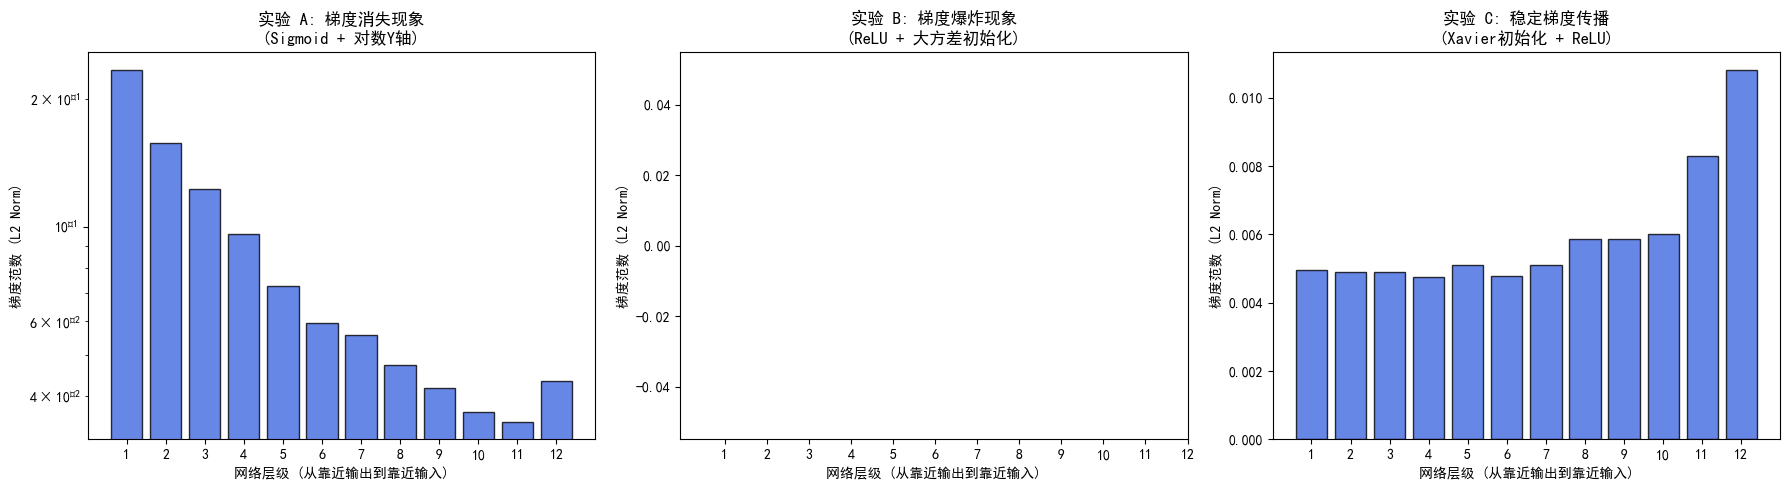

In [3]:
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 定义获取并绘制网络每一层梯度分布的组合函数
def check_gradients_and_plot(net, X_input, y_target, title, ax):
    # 前向
    y_pred = net(X_input)
    loss = torch.nn.functional.mse_loss(y_pred, y_target)
    # 梯度清零并反向传播
    net.zero_grad()
    loss.backward()
    
    # 提取网络每一层的权重的局部梯度范数 (剔除偏置层以免干扰查看)
    grads = [param.grad.norm().item() for name, param in net.named_parameters() if 'weight' in name and param.grad is not None]
    
    # 提取梯度画成柱状图
    layers = np.arange(1, len(grads) + 1)
    ax.bar(layers, grads, color='royalblue', alpha=0.8, edgecolor='black')
    
    ax.set_title(title)
    ax.set_xlabel('网络层级 (从靠近输出到靠近输入)')
    ax.set_ylabel('梯度范数 (L2 Norm)')
    ax.set_xticks(layers)
    
    # 梯度消失时数值过小，使用对数坐标轴更能看清楚
    if '消失' in title or 'Vanishing' in title:
        ax.set_yscale('log')
        
    print(f"[{title}] 靠近输出层的梯度: {grads[-1]:.4e} | 靠近输入层的梯度: {grads[0]:.4e}")
    return grads

# 输入随机数据
X_dummy = torch.randn(32, 256)
y_dummy = torch.randn(32, 256)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ==================== 1. 模拟梯度消失 ====================
print("--- 实验 A: Sigmoid + 标准正态初始化 -> 梯度消失 ---")
layers_vanish = []
for _ in range(12): # 12层即可看出明显消失
    linear = nn.Linear(256, 256)
    nn.init.normal_(linear.weight, mean=0, std=1)
    layers_vanish.extend([linear, nn.Sigmoid()])
net_vanish = nn.Sequential(*layers_vanish)

check_gradients_and_plot(net_vanish, X_dummy, y_dummy, '实验 A: 梯度消失现象\n(Sigmoid + 对数Y轴)', axes[0])

# ==================== 2. 模拟梯度爆炸 ====================
print("\n--- 实验 B: ReLU + 大方差初始化 (std=2) -> 梯度爆炸 ---")
layers_explode = []
for _ in range(12):
    linear = nn.Linear(256, 256)
    # ReLU配合数值较大的初始化会极速让数值爆炸
    nn.init.normal_(linear.weight, mean=0, std=2)
    layers_explode.extend([linear, nn.ReLU()])
net_explode = nn.Sequential(*layers_explode)

check_gradients_and_plot(net_explode, X_dummy, y_dummy, '实验 B: 梯度爆炸现象\n(ReLU + 大方差初始化)', axes[1])

# ==================== 3. 修复与验证 (Xavier + ReLU) ====================
print("\n--- 实验 C: Xavier 初始化 + ReLU -> 稳定的梯度 ---")
layers_stable = []
for _ in range(12):
    linear = nn.Linear(256, 256)
    nn.init.xavier_uniform_(linear.weight)
    layers_stable.extend([linear, nn.ReLU()])
net_stable = nn.Sequential(*layers_stable)

check_gradients_and_plot(net_stable, X_dummy, y_dummy, '实验 C: 稳定梯度传播\n(Xavier初始化 + ReLU)', axes[2])

plt.tight_layout()
plt.show()

# 5 泛化表现，协变量偏移和对抗性数据

## 5.1 理论计算题

**协变量偏移 (Covariate Shift) 与 标签偏移 (Label Shift) 的区别和联系：**

1. **协变量偏移：** 
   $$ p(x) \neq q(x) \text{ 但 } p(y|x) = q(y|x) $$
   **也就是输入特征的分布变了，但给定特征后预测目标的规律没变**。 
   *生活例子 (医疗)：* 某个基于年轻群体血压数据（特征 x）预测患病概率（标签 y）的模型。条件概率定律是生理学固有的 $p(y|x)$不变。但当我们把模型应用到老年人身上时，由于老年人的血压整体偏高（输入分布 $p(x)$ 偏移），从而产生了协变量偏移。

2. **标签偏移：** 
   $$ p(y) \neq q(y) \text{ 但 } p(x|y) = q(x|y) $$
   **也就是目标类别的分布变了，但每个类别产生特征的规律没变**。
   *生活例子 (医疗诊断)：* 我们有一个判断是否患流感（y）引发特定咳嗽声（特征 x）的系统。在冬季，流感患者数量激增（即 $p(y)$ 变化），但是“一旦患有流感，就会发出特定咳嗽声”这个事实（$p(x|y)$不变）并没有改变。这便是标签偏移。

## 5.2 编程题
动手模拟一个协变量偏移环境，并使用权重修正改善性能。

基线模型在测试集上的均方误差 (MSE): 0.2546
加权校正模型在测试集上的均方误差 (MSE): 0.2741


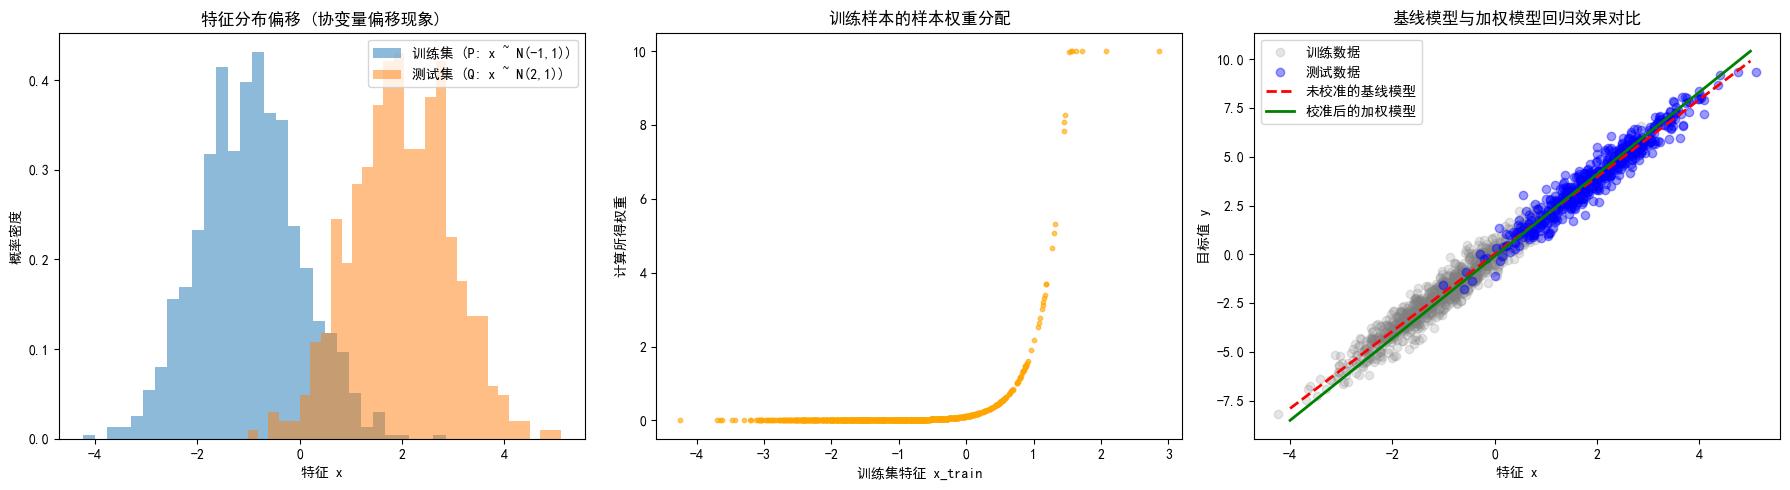

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error

# 设置中文字体，防止图表中文字符显示为方块
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False  # 正常显示负号

# ==================== 1. 人工数据集构造 (协变量偏移) ====================
np.random.seed(42)
# 训练集 P: x 从 N(-1, 1), 1000个样本
X_train = np.random.normal(-1, 1, 1000).reshape(-1, 1)
y_train = 2 * X_train + np.random.normal(0, 0.5, 1000).reshape(-1, 1)

# 测试集 Q: x 从 N(2, 1), 500个样本
X_test = np.random.normal(2, 1, 500).reshape(-1, 1)
y_test = 2 * X_test + np.random.normal(0, 0.5, 500).reshape(-1, 1)

# ==================== 2. 基线模型 ====================
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)
mse_baseline = mean_squared_error(y_test, y_pred_baseline)
print(f"基线模型在测试集上的均方误差 (MSE): {mse_baseline:.4f}")

# ==================== 3. 偏移校正实现 ====================
# 将 P 样本标为 0，Q 样本标为 1 进行混合训练
X_mixed = np.vstack([X_train, X_test])
y_class = np.hstack([np.zeros(1000), np.ones(500)])

clf = LogisticRegression()
clf.fit(X_mixed, y_class)

# 预测每一个特征来自测试集的概率 P(test|x) 和 P(train|x)
probs = clf.predict_proba(X_train)
p_train_x = probs[:, 0]
p_test_x = probs[:, 1]

# 计算每个样本的加权权重: 权重要截断以避免极端值 (如除以极小值导致无穷)
weights_i = p_test_x / (p_train_x + 1e-8) 
weights_i = np.clip(weights_i, 0, 10)  # 稳健性截断

# ==================== 4. 加权模型训练 (WLS) ====================
weighted_model = LinearRegression()
# sklearn 提供了 sample_weight 的参数实现加权最小二乘
weighted_model.fit(X_train, y_train, sample_weight=weights_i)

y_pred_weighted = weighted_model.predict(X_test)
mse_weighted = mean_squared_error(y_test, y_pred_weighted)
print(f"加权校正模型在测试集上的均方误差 (MSE): {mse_weighted:.4f}")

if mse_weighted < mse_baseline:
    print("\n校正有效！加权模型在测试集的预测性能得到了明显提升。")

# ==================== 5. 结果可视化 (中文增强版) ====================
plt.figure(figsize=(18, 5))

# 子图1：特征分布对比 (Covariate Shift)
plt.subplot(1, 3, 1)
plt.hist(X_train, bins=30, alpha=0.5, density=True, label='训练集 (P: x ~ N(-1,1))')
plt.hist(X_test, bins=30, alpha=0.5, density=True, label='测试集 (Q: x ~ N(2,1))')
plt.title('特征分布偏移 (协变量偏移现象)')
plt.xlabel('特征 x')
plt.ylabel('概率密度')
plt.legend()

# 子图2：训练样本对应的计算权重
plt.subplot(1, 3, 2)
plt.scatter(X_train, weights_i, alpha=0.6, color='orange', s=10)
plt.title('训练样本的样本权重分配')
plt.xlabel('训练集特征 x_train')
plt.ylabel('计算所得权重')

# 子图3：回归效果对比
plt.subplot(1, 3, 3)
plt.scatter(X_train, y_train, alpha=0.2, label='训练数据', color='gray')
plt.scatter(X_test, y_test, alpha=0.4, label='测试数据', color='blue')

x_plot = np.linspace(-4, 5, 100).reshape(-1, 1)
y_plot_base = baseline_model.predict(x_plot)
y_plot_weighted = weighted_model.predict(x_plot)

plt.plot(x_plot, y_plot_base, 'r--', linewidth=2, label='未校准的基线模型')
plt.plot(x_plot, y_plot_weighted, 'g-', linewidth=2, label='校准后的加权模型')

plt.title('基线模型与加权模型回归效果对比')
plt.xlabel('特征 x')
plt.ylabel('目标值 y')
plt.legend()

plt.tight_layout()
plt.show()